In [4]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
import re
from matplotlib.ticker import MaxNLocator

In [5]:
# cargar datos
df_abc = pd.read_csv('../files/hr_clean.csv')

In [6]:
df_abc.shape

(1474, 34)

### TABLA DE CORRELACIONES (variables numéricas)

In [7]:
correlacion = df_abc.select_dtypes(include="number").corr(method="pearson")
correlacion

,Unnamed: 0,age,daily_rate,distance_from_home,employee_count,employee_number,environment_satisfaction,hourly_rate,job_involvement,job_level,...,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
Unnamed: 0,1.000000,-0.010849,-0.050273,0.034242,NaN,0.992697,0.020660,0.034274,-0.006925,-0.018227,...,-0.022586,-0.067000,0.063272,-0.015226,0.020411,0.012281,-0.014764,-0.012344,-0.011569,-0.020152
age,-0.010849,1.000000,0.013368,-0.003782,NaN,-0.015304,0.010862,0.017837,0.022442,0.489064,...,0.006397,0.037140,0.039942,0.651955,-0.034728,-0.019717,0.284437,0.200850,0.197001,0.185485
daily_rate,-0.050273,0.013368,1.000000,-0.006546,NaN,-0.053834,0.017276,0.023287,0.049445,0.004601,...,0.000244,0.008072,0.042600,0.016850,0.009386,-0.037607,-0.034204,0.009661,-0.033352,-0.044997
distance_from_home,0.034242,-0.003782,-0.006546,1.000000,NaN,0.033661,-0.014698,0.030278,0.006508,0.004109,...,0.026710,0.006449,0.045773,0.002856,-0.023303,-0.026235,0.008578,0.017595,0.009423,0.023674
employee_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employee_number,0.992697,-0.015304,-0.053834,0.033661,NaN,1.000000,0.018730,0.035979,-0.010504,-0.020093,...,-0.020034,-0.069392,0.060268,-0.016833,0.020226,0.010066,-0.010669,-0.007557,-0.008669,-0.015853
environment_satisfaction,0.020660,0.010862,0.017276,-0.014698,NaN,0.018730,1.000000,-0.049555,-0.008620,-0.000025,...,-0.030318,0.008896,0.003890,-0.005698,-0.010574,0.028233,0.000468,0.017023,0.015344,0.005146
hourly_rate,0.034274,0.017837,0.023287,0.030278,NaN,0.035979,-0.049555,1.000000,0.042959,-0.027785,...,-0.002091,0.001840,0.049087,-0.002557,-0.013078,-0.004667,-0.019126,-0.023349,-0.026472,-0.036447
job_involvement,-0.006925,0.022442,0.049445,0.006508,NaN,-0.010504,-0.008620,0.042959,1.000000,-0.010865,...,-0.029004,0.034427,0.022569,-0.004026,-0.005283,-0.014542,-0.020585,0.009543,-0.023694,0.018521
job_level,-0.018227,0.489064,0.004601,0.004109,NaN,-0.020093,-0.000025,-0.027785,-0.010865,1.000000,...,-0.021138,0.021539,0.013924,0.782120,-0.011790,0.037738,0.534136,0.388937,0.353626,0.339034


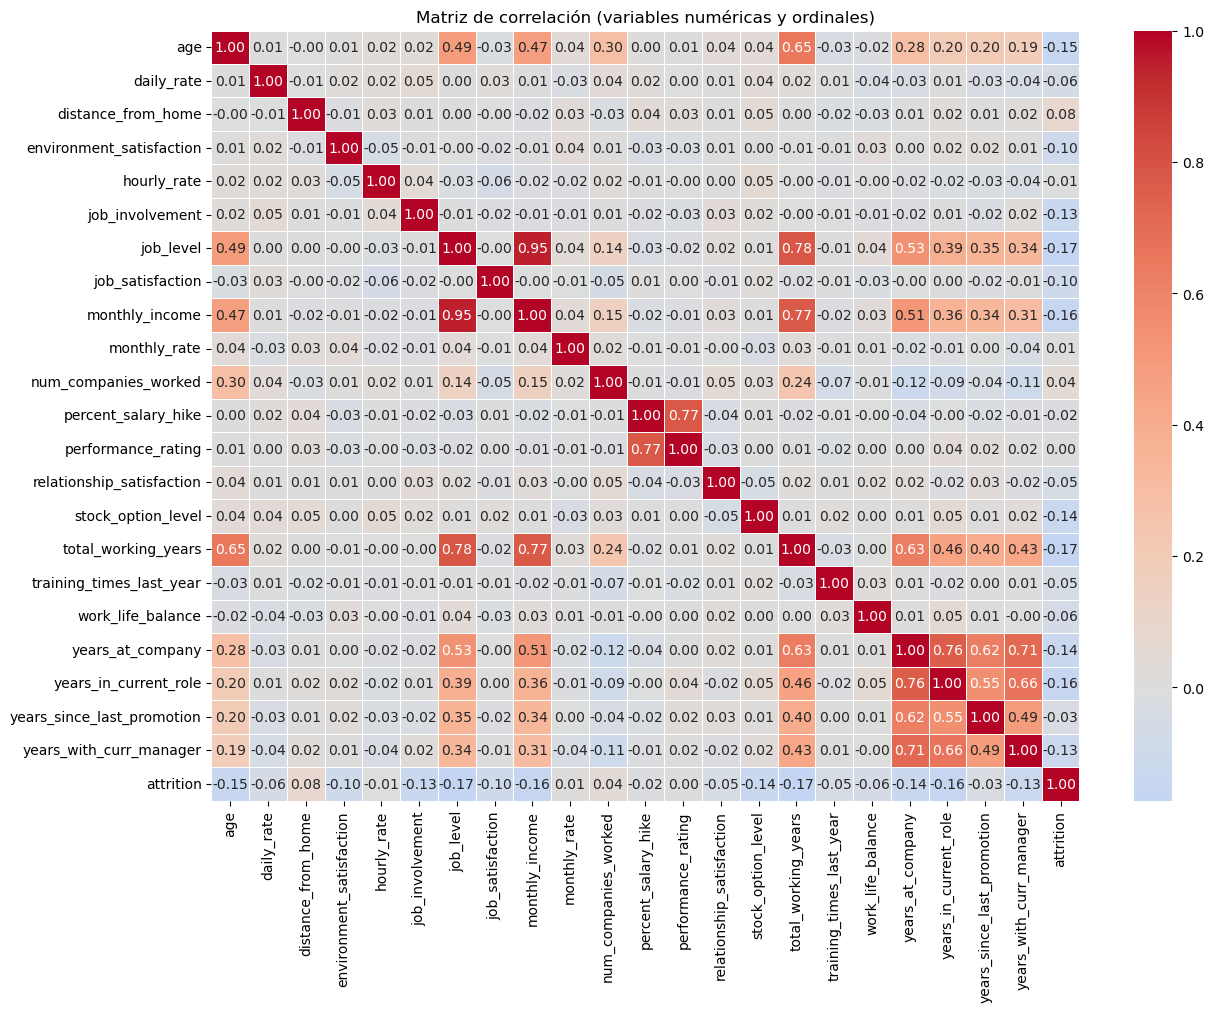

In [8]:
# limpiar columas 
cols_to_drop = ['Unnamed: 0','employee_number','employee_count']
df_corr = df_abc.drop(columns=[c for c in cols_to_drop if c in df_abc.columns])

# para sólo quedarnos con numéricas y ordinales
df_corr = df_corr.select_dtypes(include=['int64', 'float64'])

# incluir attrition en la correlación (para referncia exploratoria)
df_corr['attrition'] = df_abc['attrition'].map({'No': 0, 'Yes': 1})

# cálculo de la matriz de correlación
corr_matrix = df_corr.corr(method='pearson')

# ver valores numéricos
corr_matrix.round(2)

# visualización de la matriz de correlación
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,cmap='coolwarm',center=0,annot=True,fmt=".2f",linewidths=0.5)
plt.title('Matriz de correlación (variables numéricas y ordinales)')
plt.savefig('../outputs/proporcion_attrition/matriz_correlación.png', bbox_inches='tight')
plt.show()

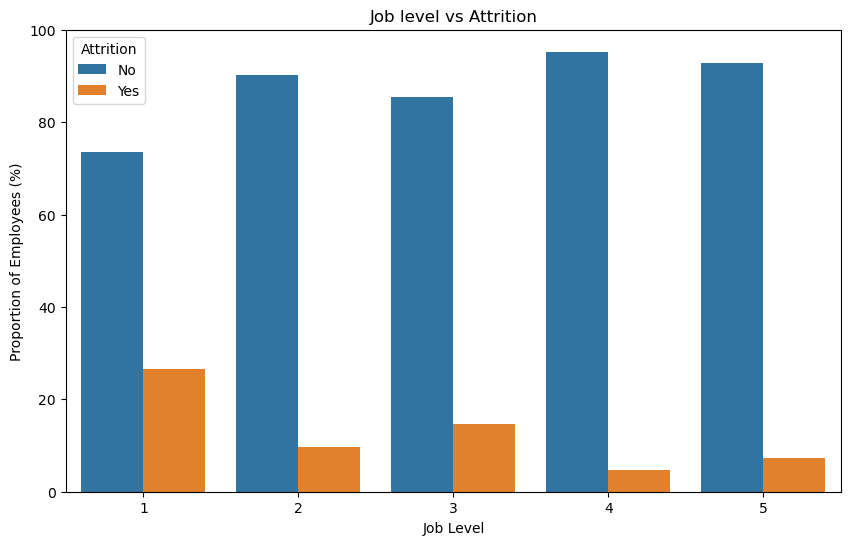

In [9]:
#job level
prop_job_level = pd.crosstab(df_abc['job_level'], df_abc['attrition'], normalize='index') * 100
prop_job_level = prop_job_level.reset_index().melt(
    id_vars='job_level', 
    var_name='attrition', 
    value_name='proportion'
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='job_level', 
    y='proportion', 
    hue='attrition', 
    data=prop_job_level, 
    hue_order=['No', 'Yes'], 
    palette='tab10'
)

plt.title('Job level vs Attrition')
plt.xlabel('Job Level')
plt.ylabel('Proportion of Employees (%)')
plt.legend(title='Attrition')

plt.show()

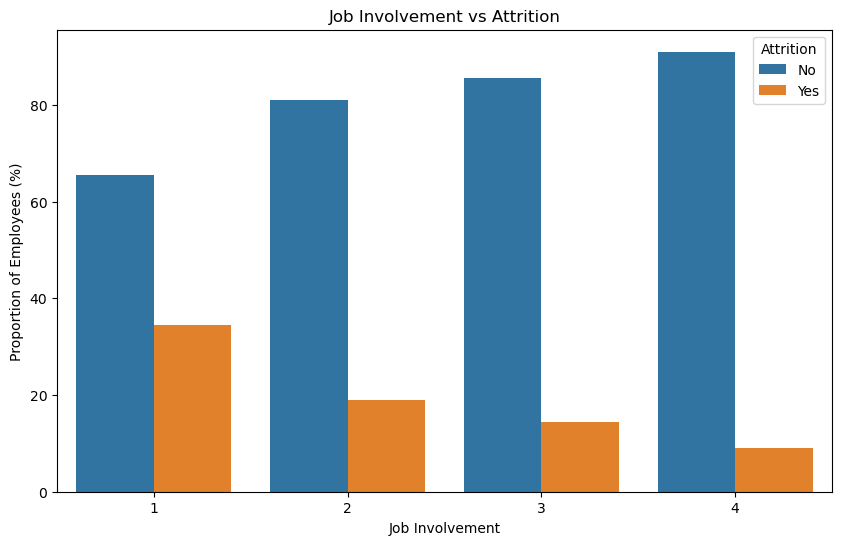

In [10]:
#job involvement
prop_involvement = pd.crosstab(df_abc['job_involvement'], df_abc['attrition'], normalize='index') * 100
prop_involvement = prop_involvement.reset_index().melt(
    id_vars='job_involvement', 
    var_name='attrition', 
    value_name='proportion'
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='job_involvement', 
    y='proportion', 
    hue='attrition', 
    data=prop_involvement, 
    hue_order=['No', 'Yes'], 
    palette='tab10'
)

plt.title('Job Involvement vs Attrition')
plt.xlabel('Job Involvement')
plt.ylabel('Proportion of Employees (%)')
plt.legend(title='Attrition')

plt.show()

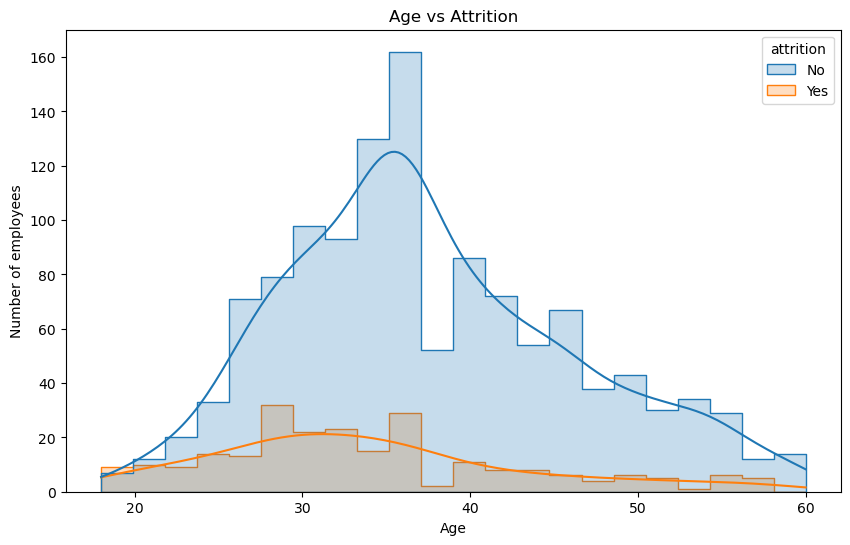

In [11]:
# Age
plt.figure(figsize=(10, 6))

sns.histplot(
    x='age', 
    hue='attrition', 
    data=df_abc, 
    hue_order=['No', 'Yes'],
    palette='tab10',
    kde=True,
    element="step",
)

plt.title('Age vs Attrition')
plt.xlabel('Age')
plt.ylabel('Number of employees')

plt.show()

C:\Users\albaj\AppData\Local\Temp\ipykernel_1876\2877619581.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\albaj\AppData\Local\Temp\ipykernel_1876\2877619581.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\albaj\AppData\Local\Temp\ipykernel_1876\2877619581.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\albaj\AppData\Local\Temp\ipykernel_1876\2877619581.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

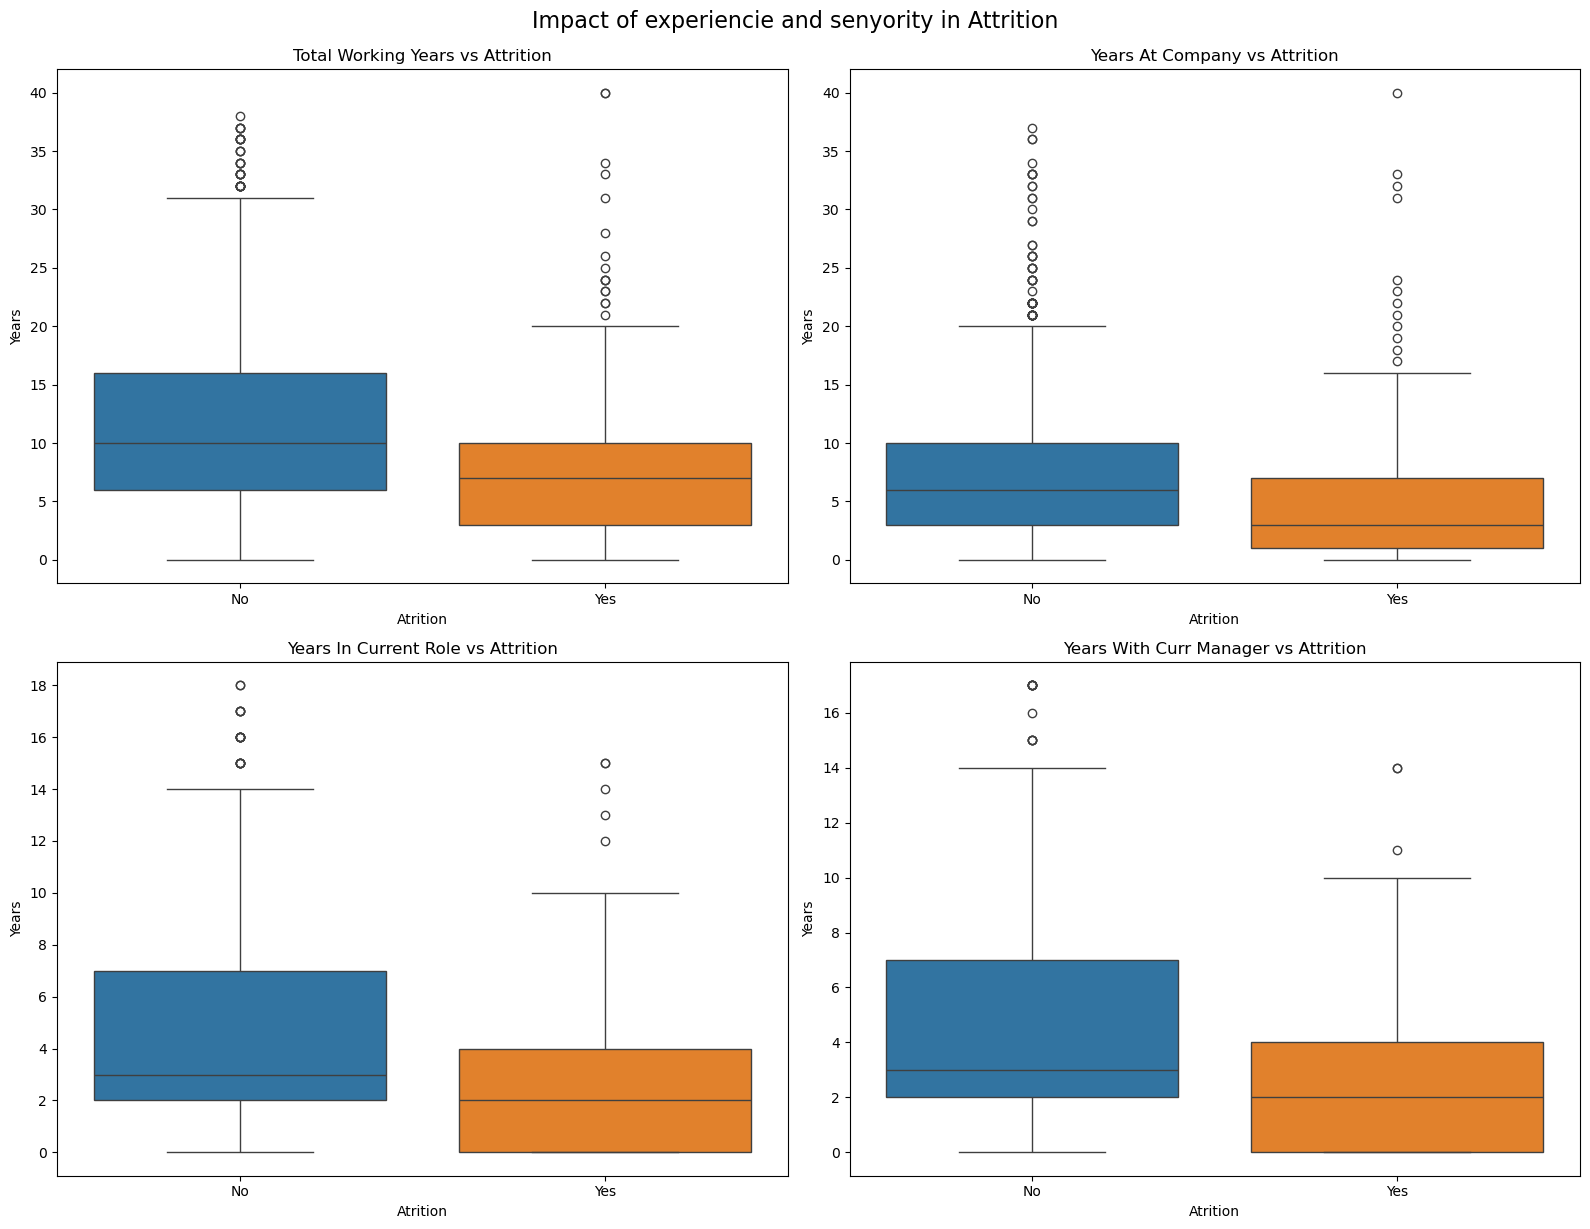

In [12]:
variables_tiempo = ['total_working_years', 'years_at_company', 'years_in_current_role', 'years_with_curr_manager']
order=['No', 'Yes']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flat

for col in variables_tiempo:
    df_abc[col] = df_abc[col].fillna(0).astype(int)

for i, col in enumerate(variables_tiempo):
    sns.boxplot(
    x='attrition',
    y=col,
    data=df_abc,
    ax=axes[i],
    palette='tab10',
    order=order
    )
    axes[i].yaxis.set_major_locator(MaxNLocator(integer=True))

    axes[i].set_title(f'{col.replace("_", " ").title()} vs Attrition')
    axes[i].set_xlabel('Atrition')
    axes[i].set_ylabel('Years')

plt.tight_layout()
plt.suptitle('Impact of experiencie and senyority in Attrition', y=1.02, fontsize=16)
plt.show()

C:\Users\albaj\AppData\Local\Temp\ipykernel_1876\3111835648.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\albaj\AppData\Local\Temp\ipykernel_1876\3111835648.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\albaj\AppData\Local\Temp\ipykernel_1876\3111835648.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\albaj\AppData\Local\Temp\ipykernel_1876\3111835648.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

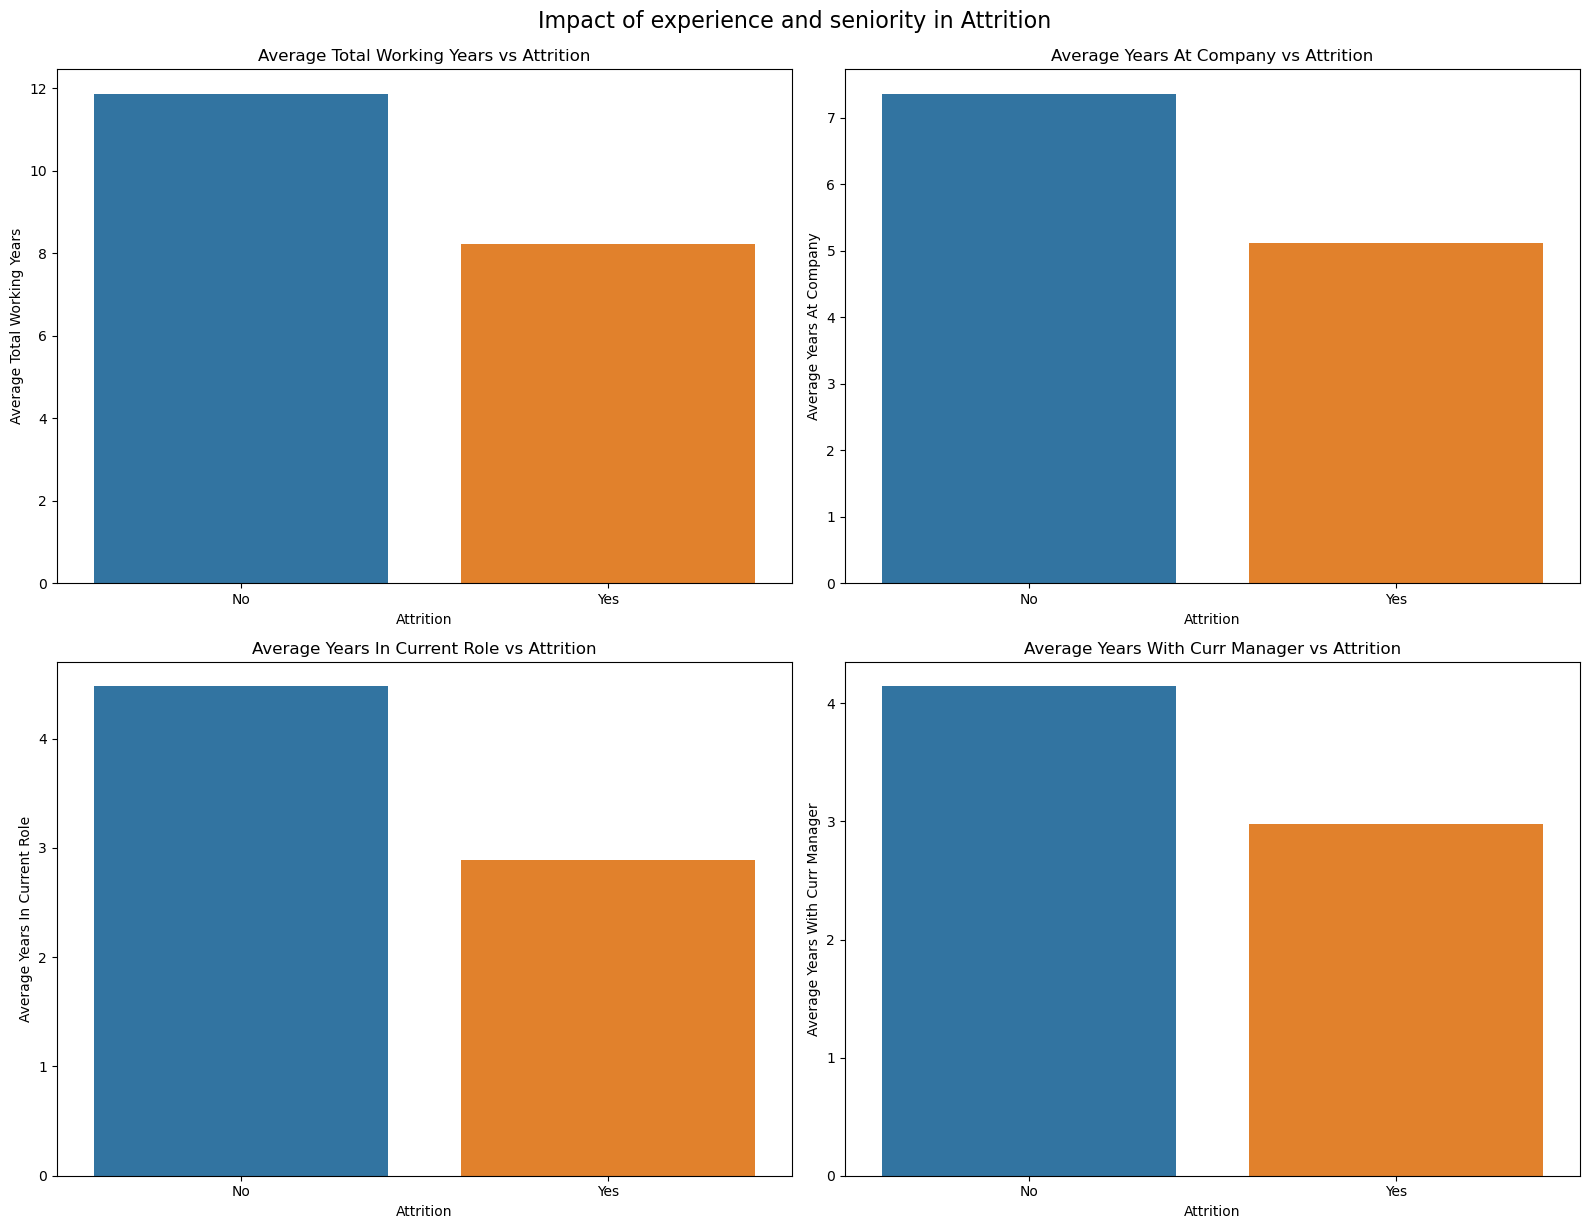

In [13]:
# Tiempo en la empresa
variables_tiempo = ['total_working_years', 'years_at_company', 'years_in_current_role', 'years_with_curr_manager']
order=['No', 'Yes']

for col in variables_tiempo:
    df_abc[col] = df_abc[col].fillna(0).astype(int)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flat

for i, col in enumerate(variables_tiempo):
    sns.barplot(
        x='attrition', 
        y=col, 
        data=df_abc,
        ax=axes[i],
        palette='tab10',
        order=order, 
        errorbar=None
    )
    axes[i].yaxis.set_major_locator(MaxNLocator(integer=True))

    axes[i].set_title(f'Average {col.replace("_", " ").title()} vs Attrition')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel('Average ' + col.replace("_", " ").title())

plt.tight_layout()
plt.suptitle('Impact of experience and seniority in Attrition', y=1.02, fontsize=16)
plt.show()

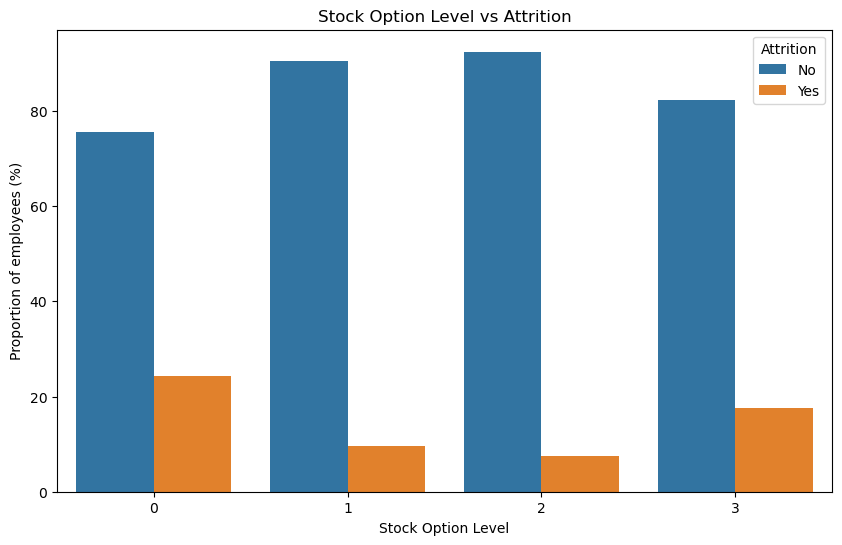

In [14]:
#stock option level
prop_stock = pd.crosstab(df_abc['stock_option_level'], df_abc['attrition'], normalize='index') * 100
prop_stock = prop_stock.reset_index().melt(
    id_vars='stock_option_level', 
    var_name='attrition', 
    value_name='proportion'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='stock_option_level',
    y='proportion', 
    hue='attrition', 
    data=prop_stock, 
    hue_order=['No', 'Yes'],
    palette='tab10'
)

plt.title('Stock Option Level vs Attrition')
plt.xlabel('Stock Option Level')
plt.ylabel('Proportion of employees (%)')
plt.legend(title='Attrition')

plt.show()

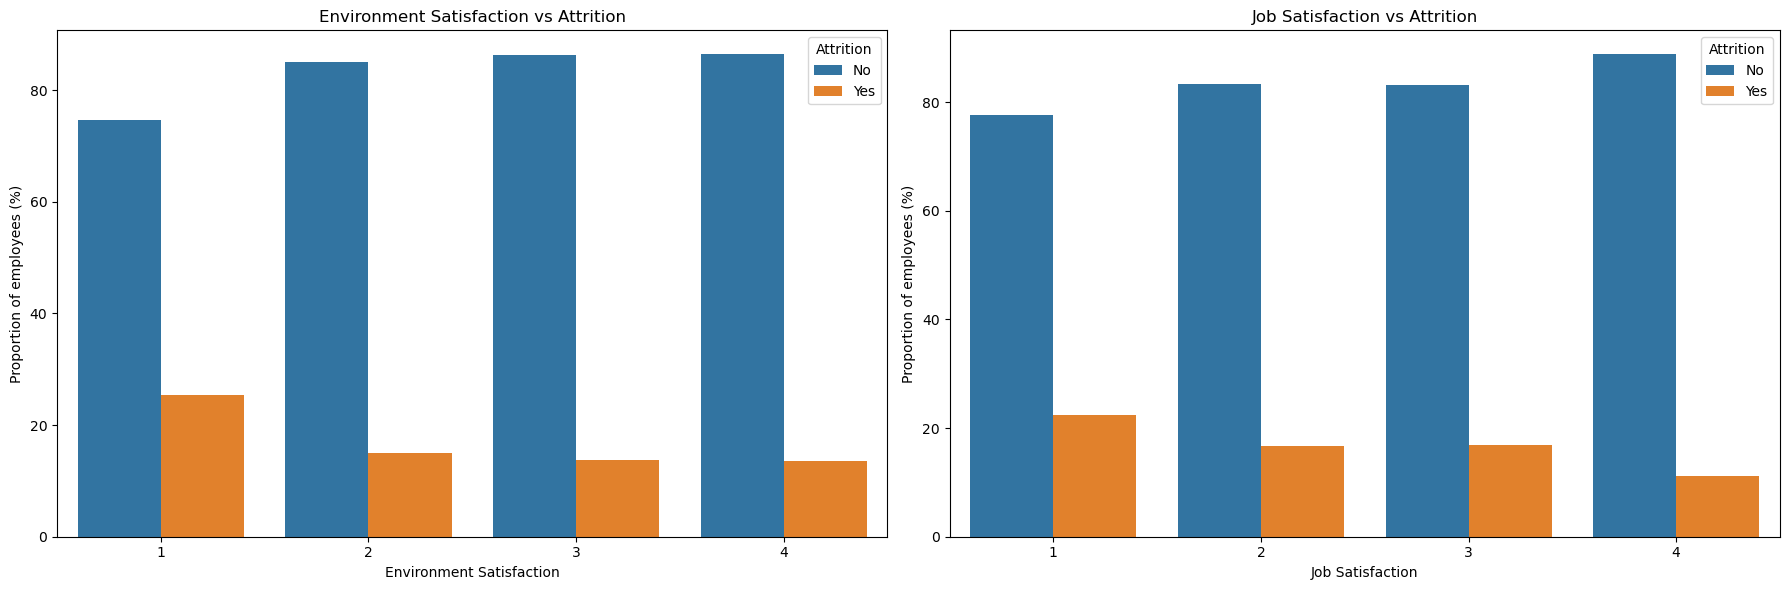

In [15]:
#satisfaccion
plt.figure(figsize=(18, 6))

# 1. Environment Satisfaction
prop_env = pd.crosstab(df_abc['environment_satisfaction'], df_abc['attrition'], normalize='index') * 100
prop_env = prop_env.reset_index().melt(id_vars='environment_satisfaction', var_name='attrition', value_name='proportion of employees')

plt.subplot(1, 2, 1)
sns.barplot(
    x='environment_satisfaction',
    y='proportion of employees', 
    hue='attrition', 
    data=prop_env, 
    hue_order=['No', 'Yes'], 
    palette='tab10'
)
plt.title('Environment Satisfaction vs Attrition')
plt.xlabel('Environment Satisfaction')
plt.ylabel('Proportion of employees (%)')
plt.legend(title='Attrition')

# 2. Job Satisfaction
prop_job = pd.crosstab(df_abc['job_satisfaction'], df_abc['attrition'], normalize='index') * 100
prop_job = prop_job.reset_index().melt(id_vars='job_satisfaction', var_name='attrition', value_name='proportion of employees')

plt.subplot(1, 2, 2)
sns.barplot(
    x='job_satisfaction',
    y='proportion of employees', 
    hue='attrition', 
    data=prop_job, 
    hue_order=['No', 'Yes'], 
    palette='tab10'
)
plt.title('Job Satisfaction vs Attrition')
plt.xlabel('Job Satisfaction')
plt.ylabel('Proportion of employees (%)')
plt.legend(title='Attrition')

plt.tight_layout()
plt.show()

In [16]:
columnas_interes = [
    'environment_satisfaction', 
    'job_satisfaction', 
    'relationship_satisfaction', 
    'work_life_balance'
]

media_satisfaccion = df_abc[columnas_interes].mean()

# Mostrem els resultats
print('Media de Satisfacción y Equilibrio')
print(media_satisfaccion)

Media de Satisfacción y Equilibrio
environment_satisfaction     2.723881
job_satisfaction             2.734057
relationship_satisfaction    2.713704
work_life_balance            2.761872
dtype: float64


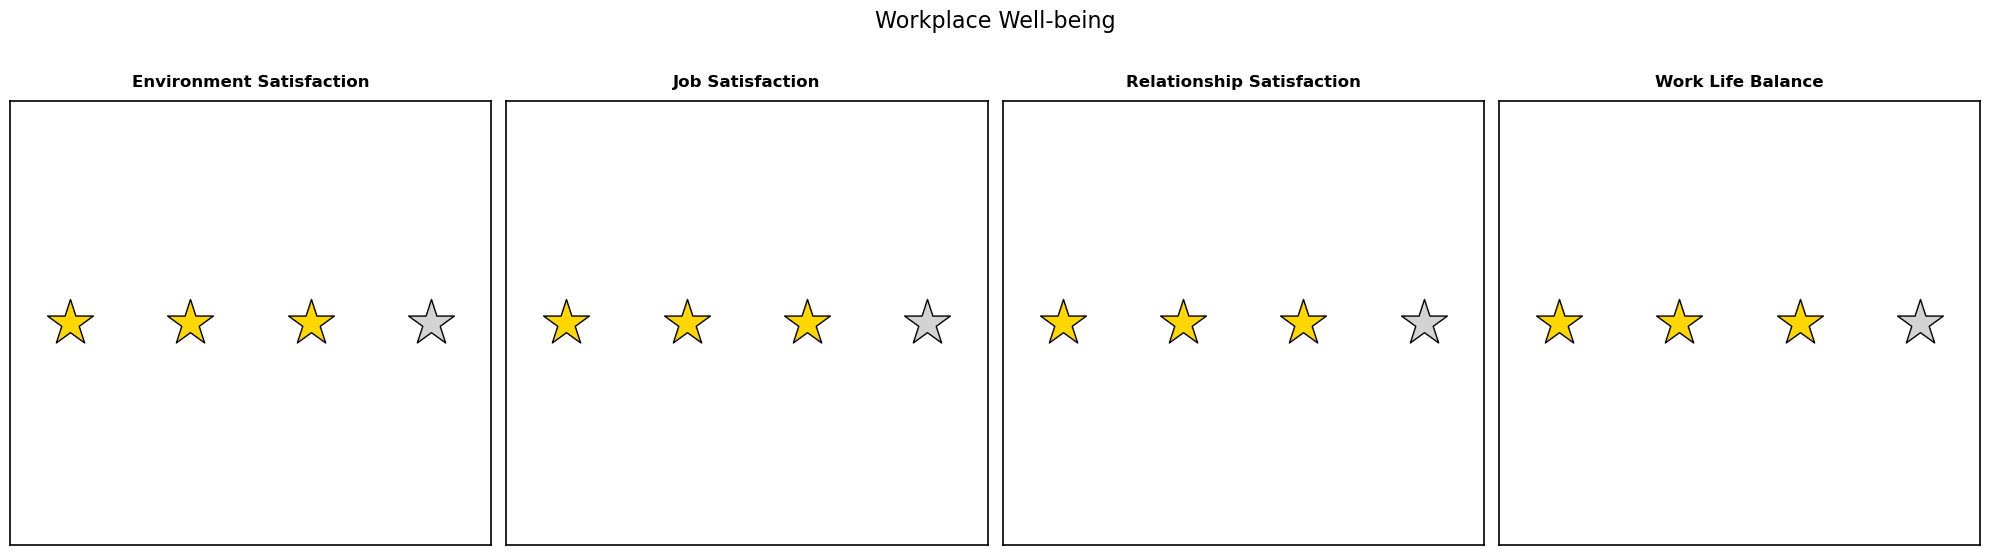

In [21]:
medias = {
    'Environment Satisfaction': 2.72,
    'Job Satisfaction': 2.73,
    'Relationship Satisfaction': 2.71,
    'Work Life Balance': 2.76
}

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
axes = axes.flatten()

for i, (nom, valor) in enumerate(medias.items()):
    ax = axes[i]
    
    for star_idx in range(1, 5):
        color = 'gold' if star_idx <= round(valor) else 'lightgrey'
        ax.scatter(star_idx, 0.5, marker='*', s=1200, color=color, edgecolors='black', zorder=3)
    
    ax.set_title(nom, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlim(0.5, 4.5)
    ax.set_ylim(0.4, 0.6)
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color('black')
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.suptitle('Workplace Well-being', y=1.1, fontsize=16)
plt.show()